In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product

In [2]:
import sys
import os
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import TrueRejection, FalseRejection, Rejection, RelativeFrobeniusNorm, rv_coefficient_adjusted, rv_coefficient, ComputeAll
from src.methods import RVPermutationTest, FitIndependent, LLKRatioTest
from src.solvers import MLE_logistic, ASE, MLE_gaussian
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
from src.plot_functions import plot_grid, plot_with_bands
import scipy.stats as stats

In [3]:
marginal_x = stats.beta
marginal_z = stats.beta
marginal_x_params = {'a': 2, 'b': 5}
marginal_z_params = {'a': 2, 'b': 5}
m = BernoulliNetwork(n=100, k=2, sigma=0)
# , marginal_x=marginal_x, marginal_z=marginal_z,
#                      marginal_x_params=marginal_x_params, marginal_z_params=marginal_z_params)

data = m.generate()
A, B, X, Z = data
rng = np.random.default_rng(1)
fitt = FitIndependent(rng=rng, solver=MLE_logistic)
Xhat, Zhat, X, Z = fitt.fit(data)

None


In [4]:
RelativeFrobeniusNorm(gram_matrix=True)(fit_out=(Xhat, Zhat, X, Z))

[np.float64(0.430618629248215), np.float64(0.4644621868607243)]

In [5]:
rv_coefficient(Xhat, Zhat), rv_coefficient(X, Z)

(np.float64(0.03498568671852969), np.float64(0.026117080057566435))

In [6]:
Qx, _ = np.linalg.qr(Xhat)
Qz, _ = np.linalg.qr(Zhat)
S = np.linalg.svd(Qx.T @ Qz, compute_uv=False)
cca_evals = S**2
wilks_score1 = np.prod(1 - cca_evals)

Qx, _ = np.linalg.qr(X)
Qz, _ = np.linalg.qr(Z)
S = np.linalg.svd(Qx.T @ Qz, compute_uv=False)
cca_evals = S**2
wilks_score2 = np.prod(1 - cca_evals)

wilks_score1, wilks_score2

(np.float64(0.9328914770447786), np.float64(0.9510644419665819))

In [ ]:
nsim = 20
n = [10, 25, 50, 100]
k = [2]
sigma = [0]
alpha = [0.05]
marginal_z = [stats.norm]
marginal_x = [stats.norm]
marginal_x_params = [{'a': 2, 'b': 5}]
marginal_z_params = [{'a': 2, 'b': 5}]
solver = [MLE_gaussian, MLE_logistic]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork, BernoulliNetwork]
methods = [RVPermutationTest, LLKRatioTest]
metrics = [ComputeAll()]
rv_coefficient_function = [rv_coefficient_adjusted]
approximation = ['F-distr']

rng = np.random.default_rng(1)

param_names = ["dgp", "method", "n", "k", "sigma", "alpha", "marginal_z", "marginal_x", 
               "edge_var", "solver", "rv_coefficient_function", "approximation", "npermutations"]

param_values = product(dgp, methods, n, k, sigma, alpha, marginal_z, marginal_x, 
                       edge_var, solver, rv_coefficient_function, approximation, npermutations)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(nsim=nsim, metrics=metrics, factorial_design=factorial_design, rng=rng, parallel=True)

Running scenarios:   0%|          | 481/307200 [00:07<1:02:36, 81.64it/s]Process SpawnPoolWorker-5:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-10:
Process SpawnPoolWorker-8:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-7:
Running scenarios:   0%|          | 960/307200 [00:07<41:11, 123.90it/s] 
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/lrcosta/opt/anaconda3/envs/network_independence/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/lrcosta/opt/anaconda3/envs/network_independence/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/lrcosta/opt/anaconda3/envs/network_independence/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  

KeyboardInterrupt: 

In [16]:
out.iloc[0]['ComputeAll']

{'Rejection': False,
 'FalseRejection': False,
 'FalseAcceptance': False,
 'TrueRejection': False,
 'TrueAcceptance': True,
 'MSE_x': np.float64(0.8456140044374092),
 'MSE_z': np.float64(4.221957251147611),
 'RelativeFrobeniusNorm_x': np.float64(1.1210466674299402),
 'RelativeFrobeniusNorm_z': np.float64(0.6914220010127345)}

In [20]:
out = pd.DataFrame(out)
out['n'] = out['args'].apply(lambda x: x['n'])
out['k'] = out['args'].apply(lambda x: x['k'])
out['edge_var'] = out['args'].apply(lambda x: x['edge_var'])

out['dgp'] = out['args'].apply(lambda x: str(x['dgp'].__name__))

out['solver'] = out['args'].apply(lambda x: str(x['solver'].__name__))
out['sigma'] = out['args'].apply(lambda x: x['sigma'])
out['method'] = out['args'].apply(lambda x: str(x['method'].__name__))
out['rv_coefficient_function'] = out['args'].apply(lambda x: str(x['rv_coefficient_function'].__name__))

out['RelativeFrobeniusNorm_x'] = out['ComputeAll'].apply(lambda x: x['RelativeFrobeniusNorm_x'])
out['RelativeFrobeniusNorm_z'] = out['ComputeAll'].apply(lambda x: x['RelativeFrobeniusNorm_z'])
out['FalseRejection'] = out['ComputeAll'].apply(lambda x: x['FalseRejection'])
out['TrueRejection'] = out['ComputeAll'].apply(lambda x: x['TrueRejection'])

In [21]:
results_gaussian = out[out['dgp'] == 'GaussianNetwork']
results_bernoulli = out[out['dgp'] == 'BernoulliNetwork']

results_null_gaussian = results_gaussian[results_gaussian['sigma'] == 0]
results_null_bernoulli = results_bernoulli[results_bernoulli['sigma'] ==0]

In [11]:
agg_gaussian_x = aggregate_results(results_gaussian, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_gaussian_z = aggregate_results(results_gaussian, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_bernoulli_x = aggregate_results(results_bernoulli, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_bernoulli_z = aggregate_results(results_bernoulli, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'solver'])

agg_gaussian_null = aggregate_results(results_null_gaussian, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_bernoulli_null = aggregate_results(results_null_bernoulli, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'solver'])

KeyError: "Column(s) ['RelativeFrobeniusNorm_x'] do not exist"

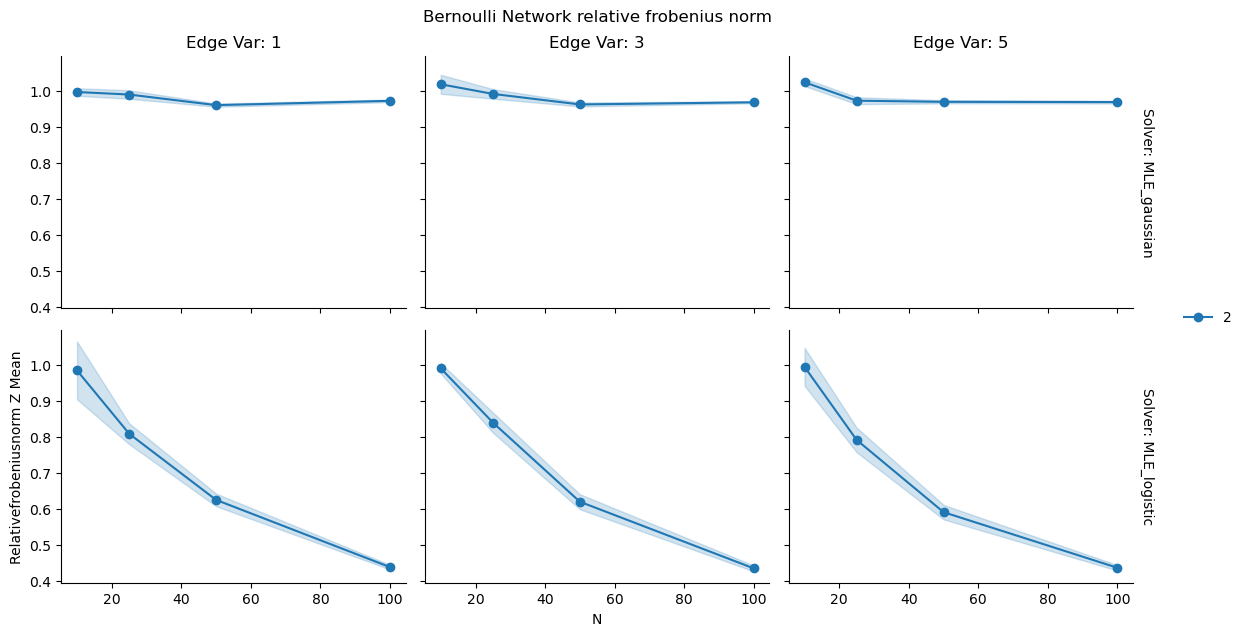

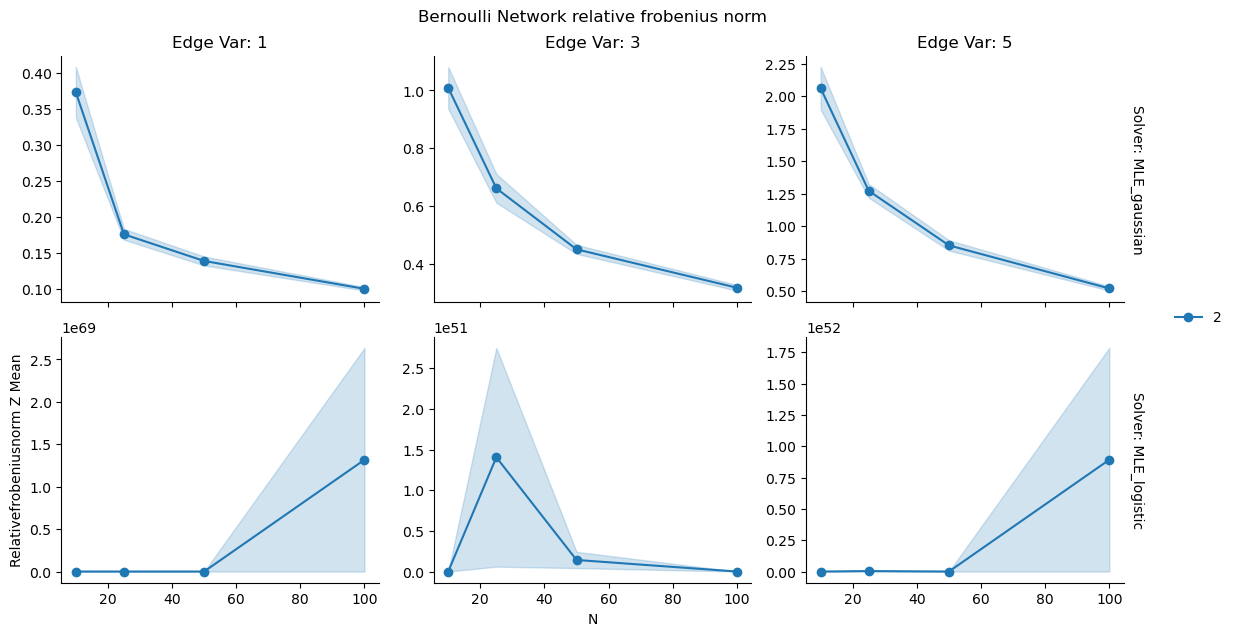

In [38]:
plot_grid(
        grouped_stats=agg_bernoulli_z,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_z_mean',
        factors=['k', 'edge_var', 'solver'],
        height=3,
        se_bands='RelativeFrobeniusNorm_z_sem',
        share_x=True,
        share_y=True,
        title='Bernoulli Network relative frobenius norm'
    )

plot_grid(
        grouped_stats=agg_gaussian_z,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_z_mean',
        factors=['k', 'edge_var', 'solver'],
        height=3,
        se_bands='RelativeFrobeniusNorm_z_sem',
        share_x=True,
        share_y=False,
        title='Bernoulli Network relative frobenius norm'
    )

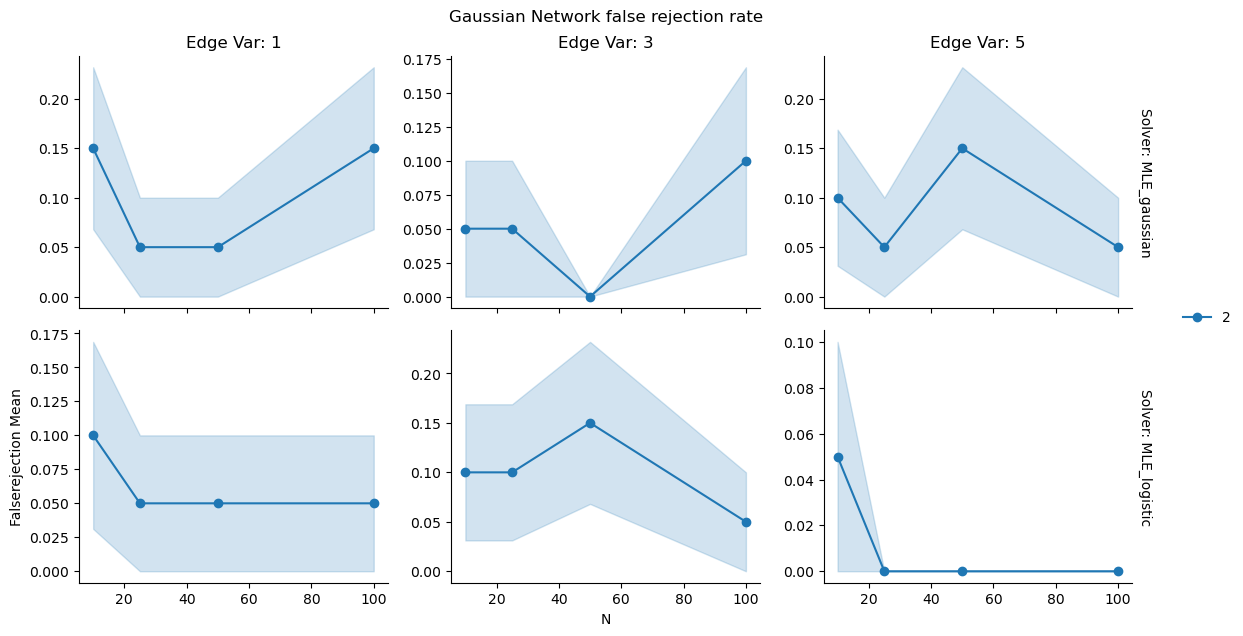

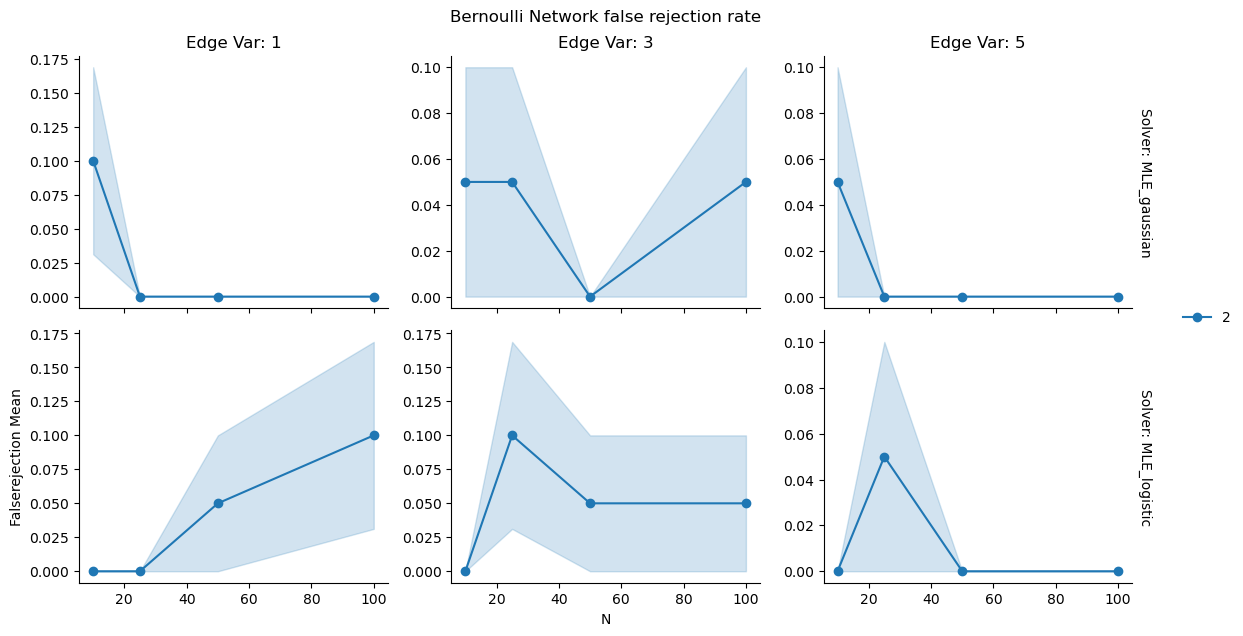

In [36]:
plot_grid(
        grouped_stats=agg_gaussian_null,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['k', 'edge_var', 'solver'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='Gaussian Network false rejection rate'
    )

plot_grid(
        grouped_stats=agg_bernoulli_null,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['k', 'edge_var', 'solver'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='Bernoulli Network false rejection rate'
    )

### Logistic rdpg solver

In [3]:
nsim = 100
n = 100
k=2
sigma=0
false_rej = 0
for i in range(nsim):
    
    rng = np.random.default_rng()
    
    md = GaussianNetwork(
    n=n,
    k=k,
    sigma=sigma,
    rng = rng,
    edge_var=1
    )
    
    A, B, X, Z = md.generate()

    method = RVPermutationTest(
        rng=rng,
        shrink=0,
        solver=MLE_gaussian,
        sigma=sigma
    )

    method.fit(A, B=B, X=X, Z=Z,
               rv_coefficient_function=rv_coefficient_adjusted)

    estimated = method.get_estimated()
    truth = method.get_truth()

    false_rej += FalseRejection()(estimated, truth)

print(false_rej / nsim)

0.03


### Testing Logistic RDPG

In [18]:
nsim = 200
n = [10, 25, 50, 100, 200, 300]
k = [2, 5]
sigma = [0, 0.1]
alpha = [0.05]
marginal_z = [stats.norm]
marginal_x = [stats.norm]
marginal_x_params = [{'a': 2, 'b': 5}]
marginal_z_params = [{'a': 2, 'b': 5}]
solver = [MLE_gaussian]
edge_var = [1, 3, 5]
dgp = [GaussianNetwork]
methods = [RVPermutationTest]
metrics = [FalseRejection(), TrueRejection(), Rejection()]
rv_coefficient_function = [rv_coefficient_adjusted, rv_coefficient]

rng = np.random.default_rng(1)

param_names = ["dgp", "method", "n", "k", "sigma", "alpha", "marginal_z", "marginal_x", 
               "edge_var", "solver", "rv_coefficient_function"]

param_values = product(dgp, methods, n, k, sigma, alpha, marginal_z, marginal_x, 
                       edge_var, solver, rv_coefficient_function)

factorial_design = [dict(zip(param_names, v)) for v in param_values]

out = run_simulation(nsim=nsim, metrics=metrics, factorial_design=factorial_design, rng=rng, parallel=True)

Running scenarios: 100%|██████████| 28800/28800 [00:57<00:00, 498.96it/s]


In [19]:
out = pd.DataFrame(out)
out['n'] = out['args'].apply(lambda x: x['n'])
out['k'] = out['args'].apply(lambda x: x['k'])
out['edge_var'] = out['args'].apply(lambda x: x['edge_var'])

out['dgp'] = out['args'].apply(lambda x: str(x['dgp'].__name__))

out['solver'] = out['args'].apply(lambda x: str(x['solver'].__name__))
out['sigma'] = out['args'].apply(lambda x: x['sigma'])
out['method'] = out['args'].apply(lambda x: str(x['method'].__name__))
out['rv_coefficient_function'] = out['args'].apply(lambda x: str(x['rv_coefficient_function'].__name__))

In [20]:
out_null = out[out['sigma']==0]
out_alt = out[out['sigma']!=0]

In [21]:
agg_out_null = aggregate_results(out_null, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'rv_coefficient_function'])
agg_out_alt = aggregate_results(out_alt, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'rv_coefficient_function'])

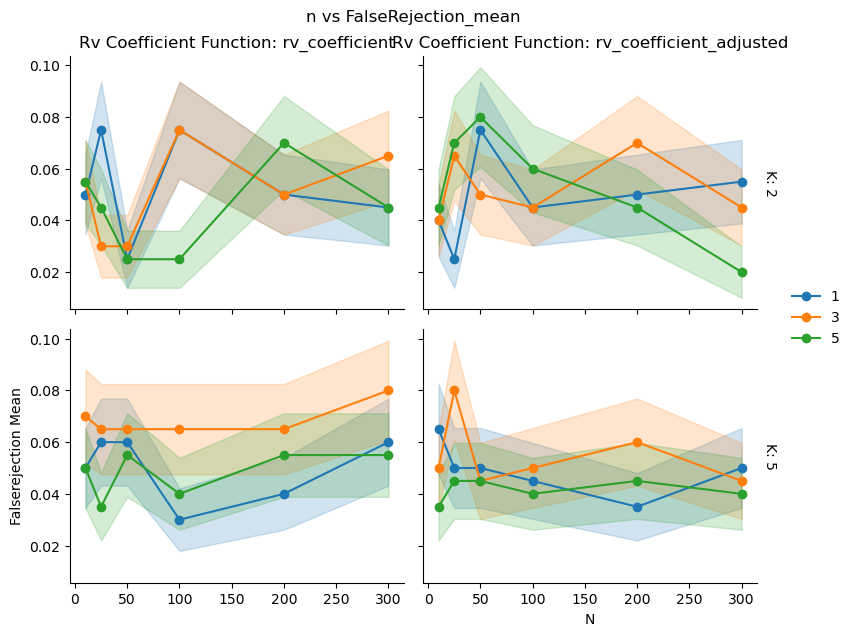

In [22]:
plot_grid(
        grouped_stats=agg_out_null,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['edge_var', 'rv_coefficient_function', 'k'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=True
    )

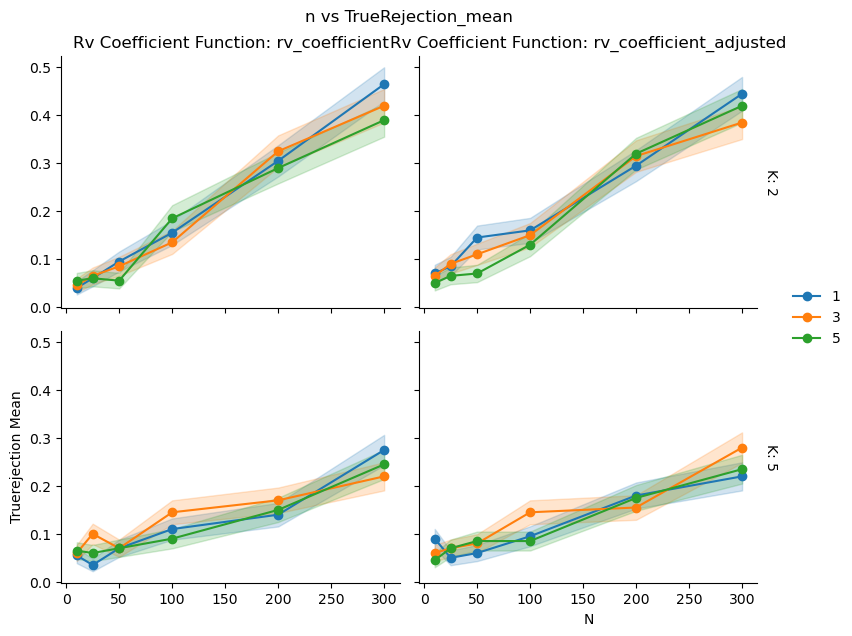

In [23]:
plot_grid(
        grouped_stats=agg_out_alt,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'rv_coefficient_function', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=True
    )

In [24]:
1/0

ZeroDivisionError: division by zero

## NORM results

In [ ]:
out = pd.DataFrame(out)
out['n'] = out['args'].apply(lambda x: x['n'])
out['k'] = out['args'].apply(lambda x: x['k'])
out['edge_var'] = out['args'].apply(lambda x: x['edge_var'])

out['dgp'] = out['args'].apply(lambda x: str(x['dgp'].__name__))

out['RelativeFrobeniusNorm_z'] = out['RelativeFrobeniusNorm'].apply(lambda x: x[1])
out['RelativeFrobeniusNorm_x'] = out['RelativeFrobeniusNorm'].apply(lambda x: x[0])

out['solver'] = out['args'].apply(lambda x: str(x['solver'].__name__))

In [ ]:
out_gaussian = out[out['dgp'] == 'GaussianNetwork']
out_bernoulli = out[out['dgp'] == 'BernoulliNetwork']

out_x_gaussian = out_gaussian.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_z'])
out_x_bernoulli = out_bernoulli.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_z'])

out_z_gaussian = out_gaussian.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_x'])
out_z_bernoulli = out_bernoulli.drop(columns=['RelativeFrobeniusNorm', 'RelativeFrobeniusNorm_x'])

out_x_gaussian_ase = out_x_gaussian[out_x_gaussian['solver'] == 'ASE']
out_x_gaussian_mle = out_x_gaussian[out_x_gaussian['solver'] == 'MLE_gaussian']
out_x_gaussian_mle_logistic = out_x_gaussian[out_x_gaussian['solver'] == 'MLE_logistic']

out_x_bernoulli_ase = out_x_bernoulli[out_x_bernoulli['solver'] == 'ASE']
out_x_bernoulli_mle = out_x_bernoulli[out_x_bernoulli['solver'] == 'MLE_gaussian']
out_x_bernoulli_mle_logistic = out_x_bernoulli[out_x_bernoulli['solver'] == 'MLE_logistic']

In [ ]:
agg_out_z_gaussian = aggregate_results(out_z_gaussian, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_out_x_gaussian = aggregate_results(out_x_gaussian, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_out_x_bernoulli = aggregate_results(out_x_bernoulli, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_out_z_bernoulli = aggregate_results(out_z_bernoulli, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'solver'])

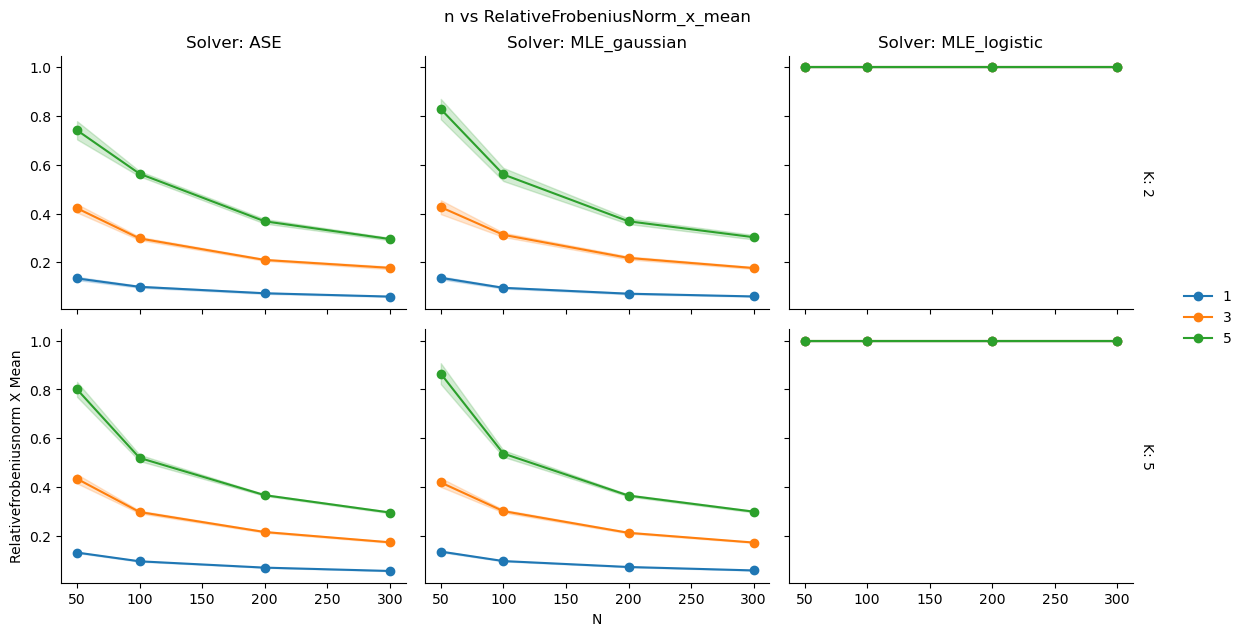

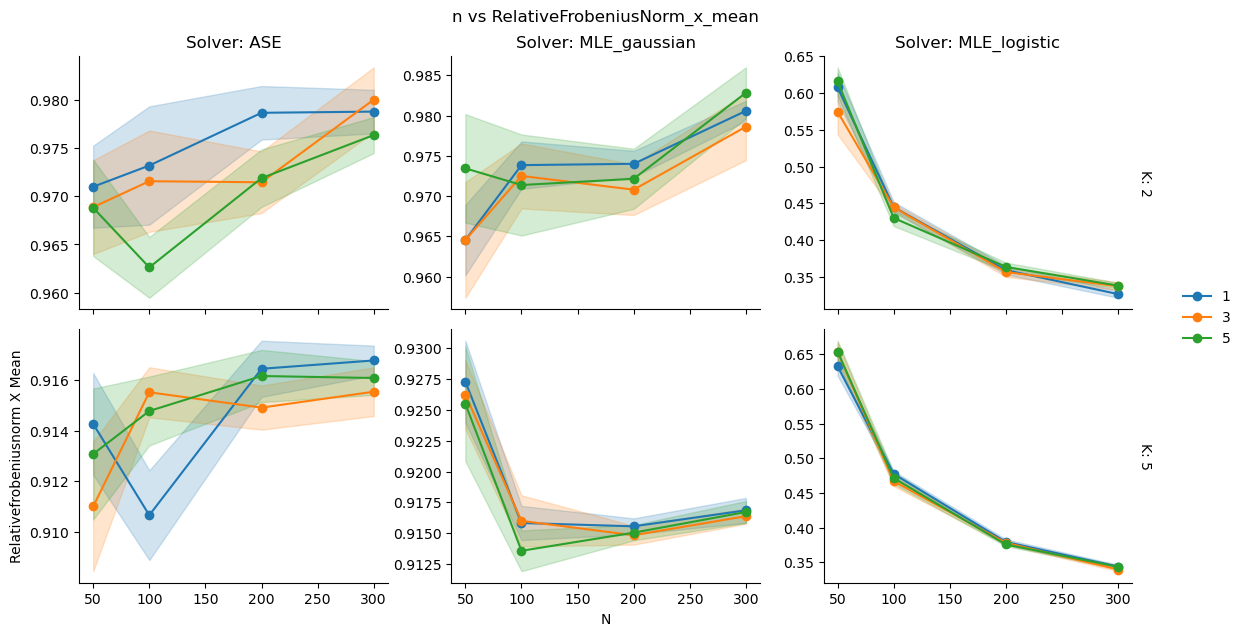

In [ ]:
from src.plot_functions import plot_grid, plot_with_bands

plot_grid(
        grouped_stats=agg_out_x_gaussian,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['edge_var', 'solver', 'k'],
        height=3,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=True
    )

plot_grid(
        grouped_stats=agg_out_x_bernoulli,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['edge_var', 'solver', 'k'],
        height=3,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=False
    )

In [ ]:
1/0

def logistic_grad(params, X, y, mu=None):
    """Utility function for scipy optimizer returning loss and gradient for logistic regression"""
    if mu is None:
        coef = params[:-1]
        mu = params[-1]
    else:
        coef = params

    logits = X @ coef + mu
    loss = np.sum(np.logaddexp(0, logits) - y * logits)
    p = expit(logits)
    error = p - y
    grad_w = X.T @ error
    return loss, grad_w

def solve_logistic_scipy(X, y, mu=None):
    """Solve logistic regression with (possibly) fixed intercept and positive coefficients

    Parameters
    ----------
    X : np.ndarray
        Feature matrix
    y : np.ndarray
        Target vector
    mu : float, optional
        Intercept term, by default None. If None estimate it

    Returns
    -------
    np.ndarray
        Coefficients of the logistic regression
    float
        Intercept term
    """
    
    n_samples, n_features = X.shape
    
    if mu is None:
        initial_params = np.zeros(n_features + 1)
        bounds = [(0, None)] * n_features + [(None, None)]
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(logistic_grad, 
                    initial_params, 
                    args=(X, y),
                    method='L-BFGS-B', 
                    bounds=bounds, 
                    jac=True)
    else:
        initial_params = np.zeros(n_features)
        bounds = [(0, None)] * n_features
        # jac=True tells scipy the objective function returns (loss, gradient)
        res = minimize(logistic_grad, 
                    initial_params, 
                    args=(X, y, mu),
                    method='L-BFGS-B', 
                    bounds=bounds, 
                    jac=True)

    return res.x[:n_features], res.x[-1] if mu is None else mu

def MLE_logistic(A, k=2, rng=None, shrink=0, **kwargs):
    #print("WARNING: MLE_logistic is experimental and might not work as expected.")
    """Maximum Likelihood Estimation for Logistic link adjacency matrix

    Parameters
    ----------
    A : np.ndarray
        Adjacency matrix
    k : int, optional
        Number of latent dimensions, by default 2
    rng : np.random.Generator, optional
        Random number generator, by default None
    shrink : int, optional
        Shrinkage parameter, by default 0

    Returns
    -------
    _type_
        _description_
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # useful quantities
    n = A.shape[0]
    
    # in the paper it seems to use the frob norm NOT squared, i get better results
    # squaring it
    a_norm_scaled = 1/(n*(n-1)) * norm(A, 'fro')**2
    
    # mean centered matrix
    A_centered = A - a_norm_scaled
    
    # from paper, mle of \mu
    mu_hat = -np.log(a_norm_scaled/(1-a_norm_scaled))
    
    # use this to fix randomness in eigsh
    v0 = rng.standard_normal(size=A_centered.shape[0])

    evals, evectors = eigsh(A_centered, k=k, which='LM', v0=v0)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evectors = evectors[:, idx]

    # build the matrix of features
    X_big = np.zeros((n*(n-1)//2, k))

    for i in range(k):
        t = np.outer(evectors[:, i], evectors[:, i])
        X_big[:, i] = t[np.triu_indices(n, k=1)] 
    
    # define as target the upper diagonal part of A (equal to lower since 
    # A symmetric)
    target = A[np.triu_indices(n, k=1)]

    # solve logistic regression with fixed mu and positive constrained coefs
    coefs, mu = solve_logistic_scipy(X_big, target, mu=mu_hat)

    xhat = evectors * np.sqrt(coefs)
    
    return [xhat], [evals]

ZeroDivisionError: division by zero